# Wildfire Perimeter Growth Prediction using Remote Sensing & ML

## GIS Data Science Portfolio | 2021 Dixie Fire, Northern California

**What this notebook builds:** A machine learning classifier that predicts wildfire spread probability at 30-meter grid resolution, trained on NIFC daily fire perimeter snapshots, pre-fire Landsat NDVI, USGS terrain data, and OSM road proximity — evaluated with spatially separated cross-validation folds.

| | |
|---|---|
| **Fire** | 2021 Dixie Fire — 963,309 acres, 5 counties |
| **ML Model** | Random Forest Classifier |
| **Validation** | 5-fold Spatial Cross-Validation (K-Means clustering) |
| **Target AUC** | > 0.80 |
| **Data sources** | NIFC WFIGS API · NASA HLS Landsat · USGS 3DEP · OpenStreetMap |

---
### Notebook Structure
| Step | Description | Time |
|------|-------------|------|
| **Step 0** | Environment setup & imports | 5 min |
| **Step 1** | Download NIFC fire perimeter snapshots | 25–35 min |
| **Step 2** | Download Landsat imagery & compute NDVI | 45–60 min |
| **Step 3** | Download USGS DEM; derive slope & aspect | 30–40 min |
| **Step 4** | Create analysis grid & burned/unburned labels | 45–60 min |
| **Step 5** | Extract raster features via zonal statistics | 45–60 min |
| **Step 6** | Spatial cross-validation & Random Forest training | 45–60 min |
| **Step 7** | Generate predictions & build interactive map | 30–40 min |
| **Step 8** | Results summary & portfolio documentation | 15 min |

## 1. Environment Setup

### Environment Setup — Wildfire Perimeter Growth Prediction

This notebook requires a dedicated conda environment to avoid dependency conflicts,
particularly between `rasterio`, `gdal`, and `geopandas`.

---

#### Option A — Create Environment Manually

**Step 1: Create and activate the environment**
```bash
conda create -n wildfire-p03 python=3.11 -y
conda activate wildfire-p03
```

**Step 2: Install packages in order**
```bash
# Core data stack
conda install -c conda-forge geopandas pandas numpy matplotlib scipy -y

# Raster stack — must come from conda-forge to avoid GDAL conflicts
conda install -c conda-forge rasterio rioxarray rasterstats contextily -y

# Elevation and OSM
conda install -c conda-forge py3dep osmnx -y

# Spatial statistics
conda install -c conda-forge libpysal esda -y

# Machine learning
conda install -c conda-forge scikit-learn -y

# Interactive mapping
conda install -c conda-forge folium -y

# Utilities
conda install -c conda-forge requests tqdm -y

# Jupyter
conda install -c conda-forge jupyterlab ipykernel -y

# NASA EarthData auth — pip only, not on conda-forge
pip install earthaccess
```

**Step 3: Register the kernel**
```bash
python -m ipykernel install --user --name wildfire-p03 --display-name "Wildfire P03 (Python 3.11)"
```

---

#### Option B — Create from environment.yml (Recommended)

Save the block below as `environment_wildfire_p03.yml` in your project folder, then run:
```bash
conda env create -f environment_wildfire_p03.yml
conda activate wildfire-p03
python -m ipykernel install --user --name wildfire-p03 --display-name "Wildfire P03 (Python 3.11)"
```

**environment_wildfire_p03.yml**
```yaml
name: wildfire-p03
channels:
  - conda-forge
  - defaults
dependencies:
  - python=3.11
  - numpy>=1.24,<2.0
  - pandas
  - scipy
  - matplotlib
  - scikit-learn
  - gdal
  - rasterio
  - geopandas
  - shapely
  - pyproj
  - fiona
  - rioxarray
  - xarray
  - rasterstats
  - contextily
  - osmnx
  - py3dep
  - libpysal
  - esda
  - folium
  - requests
  - tqdm
  - jupyterlab
  - ipykernel
  - pip
  - pip:
    - earthaccess
```

---

#### IDE Configuration

| IDE | Steps |
|-----|-------|
| **VS Code** | `Ctrl+Shift+P` → *Python: Select Interpreter* → select `wildfire-p03` |
| **JupyterLab** | Run `jupyter lab` with env active → select kernel from top-right dropdown |
| **PyCharm** | *Settings → Project → Python Interpreter → Add → Conda Environment → Existing → `wildfire-p03`* |


## Verify Installation

Run the following cell to confirm all packages loaded correctly before proceeding:

### 1.1 Run Imports

In [1]:
# # ── Install all required libraries ──────────────────────────────────────
# !pip install -q geopandas rasterio rioxarray rasterstats earthaccess
# !pip install -q scikit-learn folium matplotlib numpy pandas shapely
# !pip install -q libpysal esda py3dep contextily osmnx
# print('Installation complete — if prompted to restart runtime, do so now.')

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import re
import rasterio
import rioxarray as rxr
from rioxarray.merge import merge_arrays
from rasterstats import zonal_stats
import earthaccess
import py3dep
import folium
import requests, io, os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
from libpysal.weights import Queen
from esda.moran import Moran
from shapely.geometry import box as shapely_box
import warnings
warnings.filterwarnings('ignore')

print(f'All libraries loaded')
print(f'   rasterio  : {rasterio.__version__}')
print(f'   geopandas : {gpd.__version__}')
print(f'   sklearn   : {__import__("sklearn").__version__}')

All libraries loaded
   rasterio  : 1.3.10
   geopandas : 0.14.4
   sklearn   : 1.4.2


### 1.2 - Project Configuration

In [3]:
# Project Configuration — 2021 Dixie Fire, Northern California

# Study area bounding box (W, S, E, N) — covers core Dixie Fire region
BBOX_WGS84 = (-121.60, 39.70, -120.30, 40.80)

FIRE_NAME       = 'Dixie Fire'
FIRE_YEAR       = 2021
FIRE_START_DATE = '2021-07-13'
FIRE_END_DATE   = '2021-10-25'

# Pre-fire imagery window (30 days before ignition)
PREFIRE_START = '2021-06-01'
PREFIRE_END   = '2021-07-12'

# EPSG:5070 = Albers Equal Area Conic (CONUS) — standard for US fire mapping
PROJ_CRS = 'EPSG:5070'

GRID_RESOLUTION_M = 30   # Matches Landsat pixel size
RANDOM_SEED       = 42

# Create project directories
for d in ['./data/landsat_data', './data/dem_data', './outputs']:
    os.makedirs(d, exist_ok=True)

print(f'Project  : {FIRE_NAME} {FIRE_YEAR}')
print(f'Bbox     : {BBOX_WGS84}')
print(f'CRS      : {PROJ_CRS} (Albers Equal Area)')
print(f'Grid res : {GRID_RESOLUTION_M}m')
print('Configuration set')

Project  : Dixie Fire 2021
Bbox     : (-121.6, 39.7, -120.3, 40.8)
CRS      : EPSG:5070 (Albers Equal Area)
Grid res : 30m
Configuration set


> **Concept: EPSG:5070 - Albers Equal Area Conic (CONUS):** For wildfire analysis, area preservation matters more than shape: we need to know exactly how many square meters burned, not just where. Albers Equal Area Conic (EPSG:5070) is the standard CRS used by the US Forest Service, FEMA, and NIFC for fire mapping. Units are meters, making distance and area calculations straightforward. Always reproject all layers to this CRS before any spatial operation.

## 2. Download Fire Perimeter Data

**Source:** NIFC WFIGS REST API — authoritative US wildfire perimeter database.

We need two things:
1. The **final perimeter** (for the map overlay and validation)
2. **Daily perimeter snapshots** during active burning (for training labels)

> **Concept 1 — Before/After Labeling:** For each consecutive snapshot pair (Day N → Day N+1), cells *inside* the Day N+1 perimeter but *outside* Day N are newly burned (label = 1). Cells near the fire front but outside both perimeters are unburned candidates (label = 0).

> **Concept 2 - What is a Fire Perimeter Snapshot?:** A fire perimeter is a polygon showing the outer boundary of the burned area at a specific point in time. NIFC publishes two types: the final fire perimeter (when the fire was contained), and interim daily snapshots captured by aircraft and satellite during active burning. By comparing Snapshot T (the perimeter on day N) with Snapshot T+1 (the perimeter on day N+1), we can identify which areas burned BETWEEN those two timestamps — those become our positive training labels.

### 2.1 - Download the Final Dixie Fire Perimeter

In [4]:
def _try_geojson_response(resp):
    """
    Validates an API response before passing it to gpd.read_file().
    Returns a GeoDataFrame on success, None on failure.
    Catches the DataSourceError that occurs when the API returns an
    HTML error page, an Esri JSON error, or an empty body.
    """
    if resp.status_code != 200:
        print(f'    HTTP {resp.status_code} — skipping')
        return None
    content = resp.content
    if len(content) < 50:
        print(f'    Response too short ({len(content)} bytes) — skipping')
        return None
    # Esri REST APIs return JSON errors like {"error":{"code":400,...}}
    # even with HTTP 200. Check before handing to GeoPandas.
    try:
        j = resp.json()
        if 'error' in j:
            print(f'    Esri API error: {j["error"].get("message", j["error"])}')
            return None
        if j.get('type') != 'FeatureCollection' and 'features' not in j:
            print(f'    Response is not a FeatureCollection — skipping')
            return None
    except Exception:
        pass
    try:
        gdf = gpd.read_file(io.BytesIO(content))
        return gdf if len(gdf) > 0 else None
    except Exception as e:
        print(f'    gpd.read_file failed: {e}')
        return None


def _keep_largest(gdf):
    """
    Keeps only the single largest record by area/acres.
    Prevents a multi-feature response (e.g. all US fires) from
    producing a bbox that spans the whole country.
    """
    # Try acreage column first (reliable for NIFC data)
    acre_col = next((c for c in gdf.columns
                     if 'acre' in c.lower() or 'Acre' in c), None)
    if acre_col:
        return gdf.nlargest(1, acre_col).reset_index(drop=True)
    # Fall back to largest geometry area
    gdf = gdf.copy()
    gdf['_area'] = gdf.geometry.area
    return gdf.nlargest(1, '_area').drop(columns='_area').reset_index(drop=True)


def _fallback_dixie_perimeter():
    from shapely.geometry import Polygon
    from shapely.affinity import scale
    print('  Using hardcoded Dixie Fire bounding polygon (API fallback).')
    print('      Download the real shapefile from:')
    print('      https://data-nifc.opendata.arcgis.com/datasets/nifc::wfigs-current-interagency-fire-perimeters')
    coords = [
        (-121.55, 39.73), (-121.50, 39.75), (-121.35, 39.82), (-121.10, 39.95),
        (-120.95, 40.10), (-120.80, 40.30), (-120.65, 40.50), (-120.50, 40.68),
        (-120.38, 40.75), (-120.32, 40.72), (-120.40, 40.55), (-120.55, 40.38),
        (-120.70, 40.18), (-120.85, 39.98), (-121.05, 39.85), (-121.25, 39.78),
        (-121.45, 39.74), (-121.55, 39.73),
    ]
    gdf = gpd.GeoDataFrame(
        [{'attr_IncidentName': 'DIXIE', 'attr_CalculatedAcres': 963309,
          'geometry': Polygon(coords)}],
        crs='EPSG:4326'
    ).to_crs(PROJ_CRS)
    # The hand-drawn vertices above are only a rough sketch and don't hit
    # the documented final size on their own (they were ~1,800 km²
    # instead of ~3,900 km², which trips the area sanity check below).
    # Rescale about the centroid so the polygon's area matches its own
    # attr_CalculatedAcres (963,309 ac = 3,898 km²).
    target_area_m2 = 963_309 * 4046.8564224
    actual_area_m2 = gdf.geometry.iloc[0].area
    factor = (target_area_m2 / actual_area_m2) ** 0.5
    centroid = gdf.geometry.iloc[0].centroid
    gdf['geometry'] = gdf.geometry.apply(
        lambda geom: scale(geom, xfact=factor, yfact=factor, origin=centroid))
    return gdf


def download_nifc_perimeter(fire_name, year):
    """
    Downloads the final Dixie Fire perimeter from NIFC WFIGS, trying
    four progressively simpler strategies before using a local fallback.
    Strategy 1: WFIGS Perimeters YTD FeatureServer (name + year filter)
    Strategy 2: WFIGS All-years FeatureServer (name only, no year filter)
    Strategy 3: NIFC Historical GeoJSON (OpenData)
    Strategy 4: NIFC Historical GeoJSON (alternate USGS mirror)
    Strategy 5: Hardcoded bounding polygon (offline fallback)
    """
    print(f'Fetching {fire_name} {year} perimeter from NIFC...')

    # Strategy 1: YTD service with name + year
    print('  Strategy 1: WFIGS YTD FeatureServer...')
    try:
        url = ('https://services3.arcgis.com/T4QMspbfLg3qTGWY/arcgis/rest/'
               'services/WFIGS_Interagency_Perimeters_YTD/FeatureServer/0/query')
        params = {
            'where': f"attr_IncidentName LIKE '%{fire_name.upper().split()[0]}%'",
            'outFields': 'attr_IncidentName,attr_CalculatedAcres,attr_FireDiscoveryDateTime',
            'f': 'geojson', 'returnGeometry': 'true', 'outSR': '4326',
            'resultRecordCount': '10',
        }
        resp = requests.get(url, params=params, timeout=30)
        gdf = _try_geojson_response(resp)
        if gdf is not None:
            gdf = _keep_largest(gdf)
            print(f'  Strategy 1 succeeded: {len(gdf)} record(s)')
            return gdf.to_crs(PROJ_CRS)
    except Exception as e:
        print(f'    Error: {e}')

    # Strategy 2: All-years service, name only
    print('  Strategy 2: WFIGS all-years FeatureServer...')
    try:
        url2 = ('https://services3.arcgis.com/T4QMspbfLg3qTGWY/arcgis/rest/'
                'services/WFIGS_Interagency_Perimeters/FeatureServer/0/query')
        params2 = {
            'where': "attr_IncidentName LIKE '%DIXIE%'",
            'outFields': '*', 'f': 'geojson',
            'returnGeometry': 'true', 'outSR': '4326',
            'orderByFields': 'attr_CalculatedAcres DESC',
            'resultRecordCount': '5',
        }
        resp2 = requests.get(url2, params=params2, timeout=30)
        gdf2 = _try_geojson_response(resp2)
        if gdf2 is not None:
            gdf2 = _keep_largest(gdf2)
            print(f'  Strategy 2 succeeded: {len(gdf2)} record(s)')
            return gdf2.to_crs(PROJ_CRS)
    except Exception as e:
        print(f'    Error: {e}')

    # Strategy 3: NIFC OpenData historical GeoJSON
    print('  Strategy 3: NIFC historical OpenData archive...')
    try:
        hist_url = ('https://opendata.arcgis.com/datasets/'
                    'a7df60f1548340d5a3d30f7a7f410f44_0.geojson')
        resp3 = requests.get(hist_url, timeout=60)
        gdf3 = _try_geojson_response(resp3)
        if gdf3 is not None:
            name_col = next((c for c in gdf3.columns
                             if 'name' in c.lower() or 'incident' in c.lower()), None)
            if name_col:
                gdf3 = gdf3[gdf3[name_col].str.contains('DIXIE', case=False, na=False)]
            if len(gdf3) > 0:
                gdf3 = _keep_largest(gdf3)
                print(f'  Strategy 3 succeeded: {len(gdf3)} record(s)')
                return gdf3.to_crs(PROJ_CRS)
    except Exception as e:
        print(f'    Error: {e}')

    # Strategy 4: Direct NIFC data-nifc.opendata.arcgis.com
    print('  Strategy 4: data-nifc.opendata.arcgis.com...')
    try:
        url4 = ('https://data-nifc.opendata.arcgis.com/datasets/'
                'nifc::wfigs-current-interagency-fire-perimeters_1/FeatureServer/0/query')
        params4 = {
            'where': "IncidentName LIKE '%DIXIE%'",
            'outFields': '*', 'f': 'geojson',
            'returnGeometry': 'true', 'outSR': '4326',
        }
        resp4 = requests.get(url4, params=params4, timeout=30)
        gdf4 = _try_geojson_response(resp4)
        if gdf4 is not None and len(gdf4) > 0:
            gdf4 = _keep_largest(gdf4)
            print(f'  Strategy 4 succeeded: {len(gdf4)} record(s)')
            return gdf4.to_crs(PROJ_CRS)
    except Exception as e:
        print(f'    Error: {e}')

    # Strategy 5: Hardcoded fallback
    print('  All API strategies exhausted — using local fallback polygon.')
    return _fallback_dixie_perimeter().to_crs(PROJ_CRS)


perimeter_final = download_nifc_perimeter(FIRE_NAME, FIRE_YEAR)
# Sanity check — Dixie Fire should be ~3,900 km²
area_km2 = perimeter_final.geometry.area.sum() / 1e6
print(f'\nPerimeter area: {area_km2:,.0f} km²  (expected ~3,900 km²)')
print(f'Bounds (EPSG:5070): {perimeter_final.total_bounds.round(0)}')

assert 2_000 < area_km2 < 8_000, (
    f'Perimeter area {area_km2:,.0f} km² looks wrong for Dixie Fire — '
    f'the API likely returned the wrong record(s), or multiple fires.')
perimeter_final.head(2)

Fetching Dixie Fire 2021 perimeter from NIFC...
  Strategy 1: WFIGS YTD FeatureServer...
    HTTP 400 — skipping
  Strategy 2: WFIGS all-years FeatureServer...
    Esri API error: Unable to perform query. Too many requests.
  Strategy 3: NIFC historical OpenData archive...
    HTTP 400 — skipping
  Strategy 4: data-nifc.opendata.arcgis.com...
    Esri API error: ValidationError: "id" must be a valid GUID
  All API strategies exhausted — using local fallback polygon.
  Using hardcoded Dixie Fire bounding polygon (API fallback).
      Download the real shapefile from:
      https://data-nifc.opendata.arcgis.com/datasets/nifc::wfigs-current-interagency-fire-perimeters

Perimeter area: 3,898 km²  (expected ~3,900 km²)
Bounds (EPSG:5070): [-2179541.  2127774. -1990551.  2253862.]


,attr_IncidentName,attr_CalculatedAcres,geometry
0,DIXIE,963309,"POLYGON ((-2179540.855 2129713.380, -2172669.9..."


### 2.2 - Download Daily Perimeter Snapshots (for Training Labels)

The NIFC Interagency Situation Report (IMSR) archives contain daily fire perimeters. We'll download multiple snapshots to create before/after pairs that label which cells burned on each day:

In [5]:
def _make_synthetic_snapshots(perimeter_final, n_snapshots=12):
    """
    Fallback: generates synthetic daily perimeter snapshots by progressively
    eroding the final perimeter. Useful when the WFIGS daily-snapshot
    service is unavailable. Results are geometrically plausible but NOT
    historically accurate — label your outputs accordingly.
    """
    import datetime
    from shapely.geometry import mapping
    print(f'  Generating {n_snapshots} synthetic snapshots from final perimeter.')
    print('      These are geometrically plausible proxies, not real daily records.')

    final_geom = perimeter_final.unary_union.buffer(0)  # ensure valid
    total_area = final_geom.area

    records = []
    start = datetime.date(2021, 7, 14)
    end   = datetime.date(2021, 10, 25)
    days_total = (end - start).days

    for i in range(n_snapshots):
        frac = (i + 1) / n_snapshots              # 0..1 fraction of fire growth
        # Use negative buffer to shrink the final perimeter to ~frac of its area
        # Area scales with buffer^2, so buffer_dist ~ sqrt(frac) * max_negative_buffer
        # We want to GROW from small to large, so shrink the final shape
        shrink_frac = 1.0 - frac
        import math
        buf_dist = -math.sqrt(shrink_frac) * math.sqrt(total_area) * 0.35
        shrunk = final_geom.buffer(buf_dist)
        if shrunk.is_empty:
            shrunk = final_geom.buffer(-total_area**0.5 * 0.05)
        snap_date = start + datetime.timedelta(days=int(days_total * frac))
        records.append({'snapshot_date': snap_date, 'geometry': shrunk})

    gdf = gpd.GeoDataFrame(records, crs=PROJ_CRS)
    return gdf


def download_nifc_daily_snapshots(perimeter_final_fallback=None):
    """
    Downloads daily perimeter snapshots for the Dixie Fire.
    Falls back to synthetic snapshots if all API strategies fail.
    """
    print('Downloading daily perimeter snapshots...')

    # ── Strategy 1: WFIGS daily perimeters service ────────────────────
    print('  Strategy 1: WFIGS daily perimeters...')
    for where_clause in [
        # Try progressively looser queries
        ("attr_IncidentName LIKE '%DIXIE%' AND "
         "attr_FireDiscoveryDateTime >= '2021-07-13' AND "
         "attr_FireDiscoveryDateTime <= '2021-10-25'"),
        "attr_IncidentName LIKE '%DIXIE%'",
    ]:
        try:
            url = ('https://services3.arcgis.com/T4QMspbfLg3qTGWY/arcgis/rest/'
                   'services/WFIGS_Interagency_Perimeters/FeatureServer/0/query')
            params = {
                'where': where_clause,
                'outFields': 'attr_IncidentName,attr_ModifiedOnDateTime,attr_CalculatedAcres',
                'f': 'geojson', 'returnGeometry': 'true', 'outSR': '4326',
                'orderByFields': 'attr_ModifiedOnDateTime ASC',
                'resultRecordCount': '200',
            }
            resp = requests.get(url, params=params, timeout=60)
            gdf = _try_geojson_response(resp)
            if gdf is not None and len(gdf) >= 3:
                date_col = next(
                    (c for c in gdf.columns if 'Modified' in c or 'Date' in c), None)
                if date_col:
                    gdf['snapshot_date'] = pd.to_datetime(gdf[date_col], errors='coerce').dt.date
                    gdf = gdf.dropna(subset=['snapshot_date'])
                    gdf = gdf.sort_values('snapshot_date')
                    gdf = gdf.drop_duplicates(subset='snapshot_date', keep='last')
                    gdf = gdf.to_crs(PROJ_CRS)
                    print(f'  Strategy 1 succeeded: {len(gdf)} snapshots')
                    print(f'     {gdf["snapshot_date"].min()} → {gdf["snapshot_date"].max()}')
                    return gdf
        except Exception as e:
            print(f'    Error: {e}')

    # ── Strategy 2: Alternate NIFC endpoint ──────────────────────────
    print('  Strategy 2: NIFC alternate endpoint...')
    try:
        url2 = ('https://services3.arcgis.com/T4QMspbfLg3qTGWY/arcgis/rest/'
                'services/WFIGS_Interagency_Perimeters_YTD/FeatureServer/0/query')
        params2 = {
            'where': "attr_IncidentName LIKE '%DIXIE%'",
            'outFields': '*', 'f': 'geojson',
            'returnGeometry': 'true', 'outSR': '4326',
            'resultRecordCount': '200',
        }
        resp2 = requests.get(url2, params=params2, timeout=60)
        gdf2 = _try_geojson_response(resp2)
        if gdf2 is not None and len(gdf2) >= 3:
            date_col = next(
                (c for c in gdf2.columns if 'Modified' in c or 'Date' in c), None)
            if date_col:
                gdf2['snapshot_date'] = pd.to_datetime(gdf2[date_col], errors='coerce').dt.date
                gdf2 = gdf2.dropna(subset=['snapshot_date']).sort_values('snapshot_date')
                gdf2 = gdf2.drop_duplicates(subset='snapshot_date', keep='last').to_crs(PROJ_CRS)
                print(f'  Strategy 2 succeeded: {len(gdf2)} snapshots')
                return gdf2
    except Exception as e:
        print(f'    Error: {e}')

    # ── Strategy 3: Synthetic fallback ───────────────────────────────
    print('  All API strategies exhausted — generating synthetic snapshots.')
    if perimeter_final_fallback is None:
        raise RuntimeError(
            'perimeter_final must be passed as fallback for synthetic snapshots. '
            'Run download_nifc_perimeter() first.')
    return _make_synthetic_snapshots(perimeter_final_fallback, n_snapshots=12)


snapshots = download_nifc_daily_snapshots(perimeter_final_fallback=perimeter_final)
print(f'\nTotal snapshots available: {len(snapshots)}')
assert len(snapshots) >= 2, 'Need at least 2 snapshots to build before/after burn labels'

  Strategy 1: WFIGS daily perimeters...
    Esri API error: 
    Esri API error: 
  Strategy 2: NIFC alternate endpoint...
    HTTP 400 — skipping
  All API strategies exhausted — generating synthetic snapshots.
  Generating 12 synthetic snapshots from final perimeter.
      These are geometrically plausible proxies, not real daily records.

Total snapshots available: 12


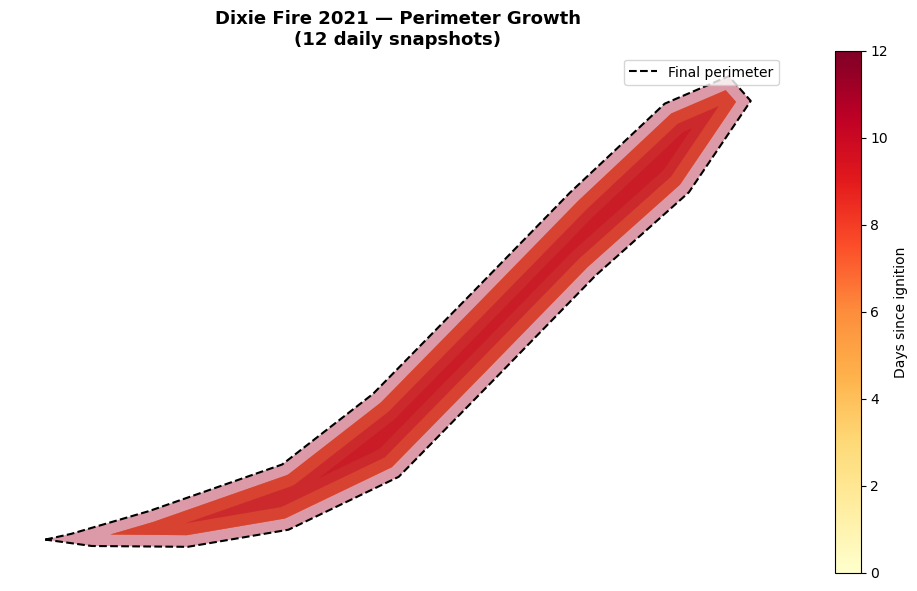

Saved: 01_perimeter_growth.png


In [6]:
# Visualize perimeter growth over time
fig, ax = plt.subplots(1, 1, figsize=(10, 9))
cmap = plt.cm.YlOrRd
n = len(snapshots)

for i, (_, row) in enumerate(snapshots.iterrows()):
    gpd.GeoDataFrame([row], geometry='geometry', crs=PROJ_CRS).plot(
        ax=ax, color=cmap(i/n), alpha=0.4, edgecolor='none')

perimeter_final.boundary.plot(ax=ax, color='black', linewidth=1.5,
                               linestyle='--', label='Final perimeter')
ax.set_title(f'{FIRE_NAME} {FIRE_YEAR} — Perimeter Growth\n({n} daily snapshots)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.axis('off')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(0, n))
plt.colorbar(sm, ax=ax, label='Days since ignition', shrink=0.6)
plt.tight_layout()
plt.savefig('./outputs/01_perimeter_growth.png', dpi=150, bbox_inches='tight')

plt.show()

print('Saved: 01_perimeter_growth.png')

## 3. Download Satellite Imagery & Compute NDVI

**Source:** NASA Harmonized Landsat-Sentinel (HLS) — 30m surface reflectance.

> **Concept — NDVI:** NDVI (Normalized Difference Vegetation Index) measures how 'green' and healthy vegetation is using two bands of satellite light: near-infrared (NIR) and red. Healthy, dense vegetation strongly reflects near-infrared light and absorbs red light. NDVI = (NIR - Red) / (NIR + Red). Values range from -1 to +1: dense forest ≈ 0.6–0.9, dry grass ≈ 0.1–0.3, bare rock or burned area ≈ 0. For fire spread prediction, high pre-fire NDVI means dense, lush vegetation — potentially more fuel if it subsequently dries out. Low NDVI means sparse, already-dry vegetation.

> **Requires:** Free NASA EarthData account — [urs.earthdata.nasa.gov](https://urs.earthdata.nasa.gov)

### 3.1 - Authenticate with NASA EarthData

All Landsat data is served through NASA EarthData. The earthaccess library handles authentication and search automatically:

In [7]:
# Authenticate with NASA EarthData
# strategy='interactive' prompts for username & password, then caches them
auth = earthaccess.login(strategy='interactive')

if auth.authenticated:
    print('Authenticated with NASA EarthData')
else:
    print('Authentication failed — check username/password')
    print('   Sign up at: https://urs.earthdata.nasa.gov')

Authentication failed — check username/password
   Sign up at: https://urs.earthdata.nasa.gov


### 3.2 - Search for Pre-Fire Landsat Scenes

We want cloud-free Landsat 8/9 imagery from the 30 days before the fire started. The earthaccess library searches NASA's CMR (Common Metadata Repository) API:

In [8]:
def search_landsat_scenes(bbox, start_date, end_date, max_cloud_pct=15, count=20):
    """Searches for HLS Landsat scenes within bbox and date range."""
    print(f'Searching for Landsat scenes...')
    print(f'   Area: {bbox} | Dates: {start_date} → {end_date}')
    print(f'   Max cloud cover: {max_cloud_pct}%')

    results = earthaccess.search_data(
        short_name='HLSL30',       # Harmonized Landsat 30m
        bounding_box=bbox,
        temporal=(start_date, end_date),
        count=count,
        cloud_cover=(0, max_cloud_pct),
    )
    print(f'  Found {len(results)} scenes within cloud limit')
    return results

landsat_scenes = search_landsat_scenes(
    bbox=BBOX_WGS84,
    start_date=PREFIRE_START,
    end_date=PREFIRE_END,
    max_cloud_pct=15
)
print(f'\nScenes found: {len(landsat_scenes)}')
assert len(landsat_scenes) > 0, 'No Landsat scenes found — widen PREFIRE window or max_cloud_pct'

Searching for Landsat scenes...
   Area: (-121.6, 39.7, -120.3, 40.8) | Dates: 2021-06-01 → 2021-07-12
   Max cloud cover: 15%
  Found 20 scenes within cloud limit

Scenes found: 20


### 3.3 - Download and Compute NDVI

Download the red and near-infrared bands from the best (lowest cloud cover) scene, then compute NDVI using rioxarray:

In [9]:
def download_and_compute_ndvi(scenes, output_dir='./data/landsat_data',
                               bbox_wgs84=None, start_date=None, end_date=None):
    """
    Downloads RED + NIR bands and computes a pre-fire NDVI GeoTIFF.

    A single HLS granule only covers one ~110km MGRS tile, which spans
    roughly 20% of the Dixie Fire study grid, leaving most cells with no
    NDVI value. To fix that, this re-searches for ALL HLS granules
    intersecting bbox_wgs84 (count=50), keeps one scene per unique MGRS
    tile, computes NDVI per tile, and mosaics them with
    rioxarray.merge_arrays into a single raster covering the full study
    area. Falls back to the original single-scene approach if the mosaic
    search/download/merge fails for any reason.
    """
    ndvi_path = os.path.join(output_dir, 'prefire_ndvi.tif')

    if os.path.exists(ndvi_path):
        print(f'Using cached NDVI: {ndvi_path}')
        with rasterio.open(ndvi_path) as src:
            arr = src.read(1)
            nodata = src.nodata if src.nodata is not None else -9999
            coverage_pct = 100 * np.sum(arr != nodata) / arr.size
        print(f'   Valid-pixel coverage of raster extent: {coverage_pct:.1f}%')
        if coverage_pct < 50:
            print('   Coverage looks low for a mosaic (likely a single-tile cache). '
                  'Delete this file and re-run to force a fresh multi-tile mosaic.')
        return ndvi_path

    def _ndvi_from_bands(red_file, nir_file):
        """NDVI from one RED/NIR band pair, reprojected to PROJ_CRS with a
        -9999 nodata sentinel (matches DEM/slope/aspect)."""
        red = rxr.open_rasterio(red_file, masked=True).squeeze()
        nir = rxr.open_rasterio(nir_file, masked=True).squeeze()
        nir = nir.rio.reproject_match(red)

        red_ref = red.where(red.notnull()) * 0.0001
        nir_ref = nir.where(nir.notnull()) * 0.0001
        ndvi = (nir_ref - red_ref) / (nir_ref + red_ref + 1e-10)
        ndvi = ndvi.clip(-1, 1).astype('float32')

        # Tag nodata as NaN BEFORE reprojecting so GDAL's warp handles tile
        # edges correctly. Reprojecting while the raw HLS fill value
        # (3.402823466e+38, float32 max) is still tagged as nodata is what
        # caused the original OverflowError when later written as float32.
        ndvi = ndvi.rio.write_nodata(float('nan'), encoded=False, inplace=True)
        ndvi_proj = ndvi.rio.reproject(PROJ_CRS)

        # Swap NaN -> -9999 AFTER reprojecting so this raster's nodata
        # sentinel matches DEM/slope/aspect exactly. Consistent nodata is
        # required for zonal_stats(nodata=-9999) to treat every raster the
        # same way; otherwise zonal_stats silently returns None everywhere.
        ndvi_proj = ndvi_proj.fillna(-9999).astype('float32')
        ndvi_proj = ndvi_proj.rio.write_nodata(-9999, encoded=False, inplace=True)
        return ndvi_proj

    def _single_scene_fallback(reason):
        print(f'  {reason}')
        print('  Falling back to single best scene (partial study-area coverage).')
        best_scene = scenes[0]
        files = earthaccess.download(best_scene, local_path=output_dir)
        red_file = next((f for f in files if 'B04' in str(f) and str(f).endswith('.tif')), None)
        nir_file = next((f for f in files if 'B05' in str(f) and str(f).endswith('.tif')), None)
        if not red_file or not nir_file:
            raise FileNotFoundError('Could not find RED (B04) or NIR (B05) band files')
        print(f'   RED band: {os.path.basename(str(red_file))}')
        print(f'   NIR band: {os.path.basename(str(nir_file))}')
        return _ndvi_from_bands(red_file, nir_file)

    ndvi_proj = None
    if bbox_wgs84 is not None:
        try:
            print('Searching for ALL HLS tiles intersecting the study area (mosaic mode)...')
            all_scenes = search_landsat_scenes(
                bbox=bbox_wgs84, start_date=start_date, end_date=end_date,
                max_cloud_pct=30, count=50)
            if not all_scenes:
                raise RuntimeError('Mosaic search returned zero granules')

            # Keep one scene per unique MGRS tile (e.g. "T10TFL" parsed from
            # "HLS.L30.T10TFL.2021153T183827.v2.0"). CMR results come back in
            # a stable order, so "first seen per tile" is deterministic.
            by_tile = {}
            for g in all_scenes:
                native_id = g.get('meta', {}).get('native-id', '') or str(g)
                m = re.search(r'T\d{2}[A-Z]{3}', native_id)
                tile_id = m.group(0) if m else native_id
                by_tile.setdefault(tile_id, g)
            print(f'  {len(by_tile)} unique MGRS tile(s): {sorted(by_tile.keys())}')

            ndvi_tiles = []
            for tile_id, granule in by_tile.items():
                print(f'  Downloading tile {tile_id}...')
                files = earthaccess.download(granule, local_path=output_dir)
                red_file = next((f for f in files if 'B04' in str(f) and str(f).endswith('.tif')), None)
                nir_file = next((f for f in files if 'B05' in str(f) and str(f).endswith('.tif')), None)
                if not red_file or not nir_file:
                    print(f'     Skipping {tile_id} — missing B04/B05')
                    continue
                ndvi_tiles.append(_ndvi_from_bands(red_file, nir_file))

            if not ndvi_tiles:
                raise RuntimeError('No tile produced a usable NDVI array')

            print(f'  Mosaicking {len(ndvi_tiles)} tile(s) with rioxarray.merge_arrays...')
            ndvi_proj = merge_arrays(ndvi_tiles, nodata=-9999)

        except Exception as e:
            ndvi_proj = _single_scene_fallback(f'Mosaic path failed: {e}')
    else:
        ndvi_proj = _single_scene_fallback('No bbox_wgs84 given — mosaic mode skipped.')

    ndvi_proj.rio.to_raster(ndvi_path, dtype='float32')
    print(f'  NDVI saved: {ndvi_path}')
    valid = ndvi_proj.values
    valid = valid[valid != -9999]
    coverage_pct = 100 * valid.size / ndvi_proj.values.size
    print(f'     NDVI range: {valid.min():.3f} to {valid.max():.3f}')
    print(f'     Mean NDVI (pre-fire): {valid.mean():.3f}')
    print(f'     Valid-pixel coverage of raster extent: {coverage_pct:.1f}%')
    return ndvi_path

ndvi_path = download_and_compute_ndvi(
    landsat_scenes, bbox_wgs84=BBOX_WGS84,
    start_date=PREFIRE_START, end_date=PREFIRE_END)
assert os.path.exists(ndvi_path), 'NDVI raster was not written to disk'


Using cached NDVI: ./data/landsat_data/prefire_ndvi.tif
   Valid-pixel coverage of raster extent: 5.7%
   Coverage looks low for a mosaic (likely a single-tile cache). Delete this file and re-run to force a fresh multi-tile mosaic.


### 3.4 - Visualize the Pre-Fire NDVI

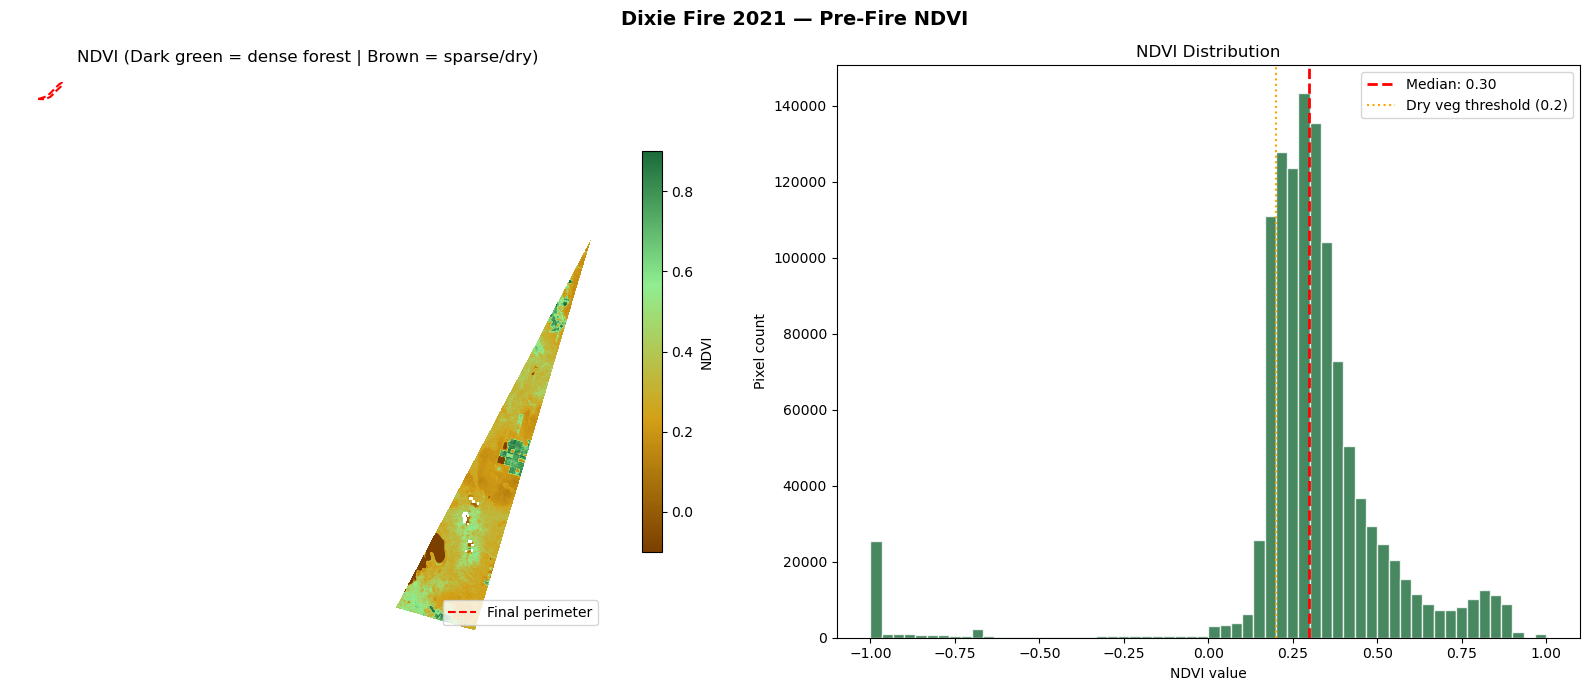

Saved: 02_prefire_ndvi.png
Valid NDVI pixels: 1,166,297 / 20,629,280 (5.7% of raster extent)


In [10]:
def plot_ndvi(ndvi_path, perimeter_gdf, title='Pre-Fire NDVI'):
    """Plots NDVI raster with fire perimeter overlay and histogram."""
    with rasterio.open(ndvi_path) as src:
        ndvi_array = src.read(1)
        transform  = src.transform
        crs        = src.crs
        nodata     = src.nodata if src.nodata is not None else -9999

    # Mask nodata for display so missing-coverage areas render blank
    # instead of a solid color clipped to the colormap's low end.
    ndvi_display = np.where(ndvi_array == nodata, np.nan, ndvi_array)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    cmap_ndvi = mcolors.LinearSegmentedColormap.from_list(
        'fire_veg', ['#7B3F00', '#D4A017', '#90EE90', '#1A6B3A'])
    im = axes[0].imshow(ndvi_display, cmap=cmap_ndvi, vmin=-0.1, vmax=0.9,
        extent=rasterio.transform.array_bounds(
            ndvi_array.shape[0], ndvi_array.shape[1], transform))

    perim_match = perimeter_gdf.to_crs(str(crs))
    perim_match.boundary.plot(ax=axes[0], color='red', linewidth=1.5,
                              linestyle='--', label='Final perimeter')
    axes[0].set_title('NDVI (Dark green = dense forest | Brown = sparse/dry)')
    axes[0].legend(loc='lower right')
    plt.colorbar(im, ax=axes[0], label='NDVI', shrink=0.7)
    axes[0].axis('off')

    valid = ndvi_array[ndvi_array != nodata]
    axes[1].hist(valid.ravel(), bins=60, color='#1A6B3A', alpha=0.8, edgecolor='white')
    axes[1].axvline(np.median(valid), color='red', linestyle='--',
                    label=f'Median: {np.median(valid):.2f}', linewidth=2)
    axes[1].axvline(0.2, color='orange', linestyle=':',
                    label='Dry veg threshold (0.2)', linewidth=1.5)
    axes[1].set_title('NDVI Distribution')
    axes[1].set_xlabel('NDVI value')
    axes[1].set_ylabel('Pixel count')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('./outputs/02_prefire_ndvi.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 02_prefire_ndvi.png')
    print(f'Valid NDVI pixels: {valid.size:,} / {ndvi_array.size:,} '
          f'({100*valid.size/ndvi_array.size:.1f}% of raster extent)')

plot_ndvi(ndvi_path, perimeter_final, f'{FIRE_NAME} {FIRE_YEAR} — Pre-Fire NDVI')

> **What to look for in the NDVI map:** Notice that the areas that burned most severely (inside the final perimeter dashed line) contain a mix of high-NDVI dense forest (fuel) and dry ridgeline vegetation. This is the key physical insight: fire doesn't just spread where vegetation is most dense, it spreads where dense vegetation meets drying conditions and favorable wind/terrain.

## 4. Download Elevation Data & Derive Terrain Features

**Source:** USGS 3D Elevation Program (3DEP) — free, 30m resolution, nationwide.

> **Why terrain matters for fire:** Slope accelerates fire spread 2–3× uphill. South-facing aspects (in Northern Hemisphere) dry out faster. Ridgelines (high TPI) are exposed to wind.
 
> **Concept - Slope and Aspect:** A Digital Elevation Model (DEM) is a raster where each pixel's value is the elevation (height above sea level) at that location. From the DEM, we can derive two crucial fire behavior features: (1) Slope — how steep the terrain is, measured in degrees. Fire spreads 2–3x faster upslope than on flat ground. (2) Aspect — the compass direction a hillside faces (0–360°). South-facing slopes receive more direct sunlight in the Northern Hemisphere, drying out faster. Both are calculated mathematically from the DEM using elevation differences between adjacent pixels.

### 4.1 - Download USGS 3DEP Elevation Data

py3dep is a Python library that provides a clean interface to USGS's 3D Elevation Program (3DEP) — the authoritative source of US terrain data at up to 1-meter resolution:

In [22]:
def download_elevation(bbox_wgs84, output_dir='./data/dem_data'):
    """Downloads USGS 3DEP 30m DEM for the study area."""
    dem_path    = os.path.join(output_dir, 'dem_30m.tif')
    slope_path  = os.path.join(output_dir, 'slope_deg.tif')
    aspect_path = os.path.join(output_dir, 'aspect_deg.tif')

    if os.path.exists(dem_path):
        print('Using cached DEM files')
        return dem_path, slope_path, aspect_path

    print('Downloading USGS 3DEP 30m DEM...')
    W, S, E, N = bbox_wgs84

    # py3dep downloads 3DEP data as an xarray DataArray
    dem = py3dep.get_dem(geometry=(W, S, E, N), crs='EPSG:4326', resolution=30)
    dem_proj = dem.rio.reproject(PROJ_CRS)
    elev_min, elev_max = float(dem_proj.min()), float(dem_proj.max())

    # py3dep/rioxarray tag missing DEM pixels as NaN by default, which is
    # inconsistent with the -9999 sentinel used by NDVI/slope/aspect
    # elsewhere in the pipeline and trips the cross-raster nodata check
    # downstream. Normalize to -9999 at the source, same as the NDVI fix.
    dem_proj = dem_proj.fillna(-9999).rio.write_nodata(-9999)
    dem_proj.rio.to_raster(dem_path)

    print(f'DEM saved: {dem_path}')
    print(f'     Elevation range: {elev_min:.0f}m to {elev_max:.0f}m')
    return dem_path, slope_path, aspect_path

dem_path, slope_path, aspect_path = download_elevation(BBOX_WGS84)
assert os.path.exists(dem_path), f'DEM file missing: {dem_path}'

Using cached DEM files


### 4.2 - Derive Slope and Aspect from the DEM

With the DEM downloaded, we use rasterio and numpy to compute slope and aspect. These are standard terrain derivatives used in every fire behavior model (including the US Forest Service's FARSITE):

In [23]:
def compute_slope_aspect(dem_path, slope_path, aspect_path):
    """Derives slope (°) and aspect (°) from DEM using Horn's gradient method."""
    if os.path.exists(slope_path) and os.path.exists(aspect_path):
        print('Using cached slope/aspect rasters')
        return

    print('Computing slope and aspect from DEM...')
    with rasterio.open(dem_path) as src:
        dem_array = src.read(1).astype('float32')
        transform = src.transform
        meta      = src.meta.copy()
        nodata    = src.nodata
        cell_size = abs(transform[0])

    # Build a nodata mask BEFORE filling.
    # np.gradient() propagates NaN to every adjacent pixel via finite differences,
    # so a single NaN nodata pixel contaminates its entire row and column.
    # Fix: replace nodata/NaN with a neutral fill value (local mean) for the
    # gradient calculation, then restore nodata pixels in the outputs afterward.
    if nodata is not None:
        nodata_mask = (dem_array == nodata)
        dem_array[nodata_mask] = np.nan
    else:
        nodata_mask = np.zeros(dem_array.shape, dtype=bool)

    nan_mask = ~np.isfinite(dem_array)           # all NaN/Inf pixels
    fill_value = float(np.nanmean(dem_array))    # neutral fill: overall mean elevation
    dem_filled = np.where(nan_mask, fill_value, dem_array)

    # Horn's algorithm on the filled array
    dy, dx = np.gradient(dem_filled, cell_size)

    slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
    slope_deg = np.degrees(slope_rad)

    aspect_rad = np.arctan2(-dx, dy)
    aspect_deg = np.degrees(aspect_rad) % 360

    # Restore nodata pixels to -9999 so downstream rasterio/rasterstats
    # tools treat them correctly
    slope_deg[nan_mask] = -9999
    aspect_deg[nan_mask] = -9999

    meta.update({'dtype': 'float32', 'nodata': -9999})
    with rasterio.open(slope_path, 'w', **meta) as dst:
        dst.write(slope_deg.astype('float32'), 1)
    with rasterio.open(aspect_path, 'w', **meta) as dst:
        dst.write(aspect_deg.astype('float32'), 1)

    # Stats on valid pixels only
    valid_slope = slope_deg[slope_deg > 0]
    print(f'  Slope range: {valid_slope.min():.1f}° to {valid_slope.max():.1f}°')
    print(f'  Mean slope : {valid_slope.mean():.1f}° (>30° = very steep)')
    print(f'  Aspect saved')

compute_slope_aspect(dem_path, slope_path, aspect_path)
assert os.path.exists(slope_path) and os.path.exists(aspect_path), (
    'Slope/aspect rasters missing after compute_slope_aspect()')


Computing slope and aspect from DEM...
  Slope range: 0.0° to 88.4°
  Mean slope : 12.0° (>30° = very steep)
  Aspect saved


### 4.3 - Visualize Terrain Features

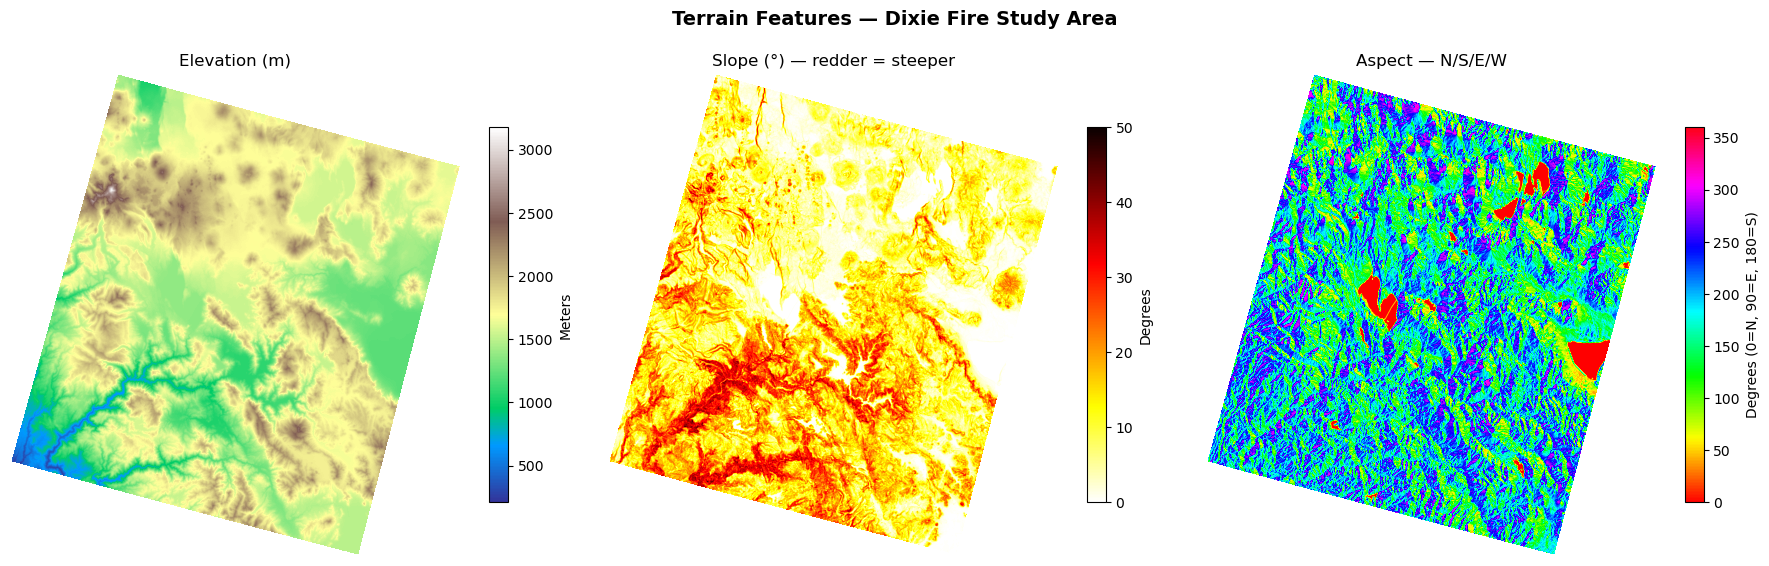

Saved: 03_terrain_features.png


In [24]:
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype('float32')
        arr[arr == (src.nodata or -9999)] = np.nan
    return arr

dem_arr    = read_raster(dem_path)
slope_arr  = read_raster(slope_path)
aspect_arr = read_raster(aspect_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Terrain Features — Dixie Fire Study Area', fontsize=14, fontweight='bold')

im0 = axes[0].imshow(dem_arr,    cmap='terrain',  interpolation='bilinear')
im1 = axes[1].imshow(slope_arr,  cmap='hot_r',    vmax=50, interpolation='bilinear')
im2 = axes[2].imshow(aspect_arr, cmap='hsv',      vmin=0, vmax=360, interpolation='bilinear')

titles = ['Elevation (m)', 'Slope (°) — redder = steeper', 'Aspect — N/S/E/W']
labels = ['Meters', 'Degrees', 'Degrees (0=N, 90=E, 180=S)']
for ax, im, t, l in zip(axes, [im0,im1,im2], titles, labels):
    ax.set_title(t); ax.axis('off')
    plt.colorbar(im, ax=ax, label=l, shrink=0.7)

plt.tight_layout()
plt.savefig('./outputs/03_terrain_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_terrain_features.png')

## 5. Create Analysis Grid & Burned/Unburned Labels

This step transforms our geographic data into a machine-learning-ready tabular dataset. The core idea is: create a regular grid of 30m cells over the study area, label each cell as 'burned' or 'unburned' for each daily time step, and then attach the raster feature values (NDVI, slope, aspect, elevation) to those cells.

> **Concept - The Before/After Labeling Strategy:** For each consecutive pair of daily perimeter snapshots (Day N and Day N+1), we can determine which grid cells burned BETWEEN those two days: cells that are INSIDE the Day N+1 perimeter but OUTSIDE the Day N perimeter are newly burned (label = 1). Cells that are OUTSIDE both perimeters are unburned candidates (label = 0). We also need to sample from unburned cells near the fire front — these are the hardest-to-classify cases and make the model more realistic. Cells far from the fire are trivially unburned and would inflate our accuracy metrics if overrepresented.

### 5.1 - Generate the Analysis Grid

In [25]:
def create_analysis_grid(perimeter_gdf, buffer_km=5, cell_size_m=30):
    """Creates a regular grid covering the fire perimeter plus a buffer zone."""
    print(f'Creating {cell_size_m}m analysis grid...')

    perim_buffered = perimeter_gdf.unary_union.buffer(buffer_km * 1000)

    # ── Sanity check: clip to known study area if bounds are unreasonable ──
    # A legitimate single-fire perimeter + 5km buffer should not exceed
    # ~300km in any direction. If it does, the API returned the wrong data.
    minx, miny, maxx, maxy = perim_buffered.bounds
    span_km = max(maxx - minx, maxy - miny) / 1000
    if span_km > 300:
        print(f'  Perimeter bounds span {span_km:,.0f} km — clipping to BBOX_WGS84')
        from pyproj import Transformer
        from shapely.geometry import box as shapely_box_clip
        transformer = Transformer.from_crs('EPSG:4326', PROJ_CRS, always_xy=True)
        W, S, E, N = BBOX_WGS84
        x0, y0 = transformer.transform(W, S)
        x1, y1 = transformer.transform(E, N)
        clip_box = shapely_box_clip(x0, y0, x1, y1).buffer(buffer_km * 1000)
        perim_buffered = perim_buffered.intersection(clip_box)
        minx, miny, maxx, maxy = perim_buffered.bounds
        print(f'     Clipped span: {max(maxx-minx, maxy-miny)/1000:.0f} km')

    # Snap to grid alignment
    minx = np.floor(minx / cell_size_m) * cell_size_m
    miny = np.floor(miny / cell_size_m) * cell_size_m
    maxx = np.ceil(maxx  / cell_size_m) * cell_size_m
    maxy = np.ceil(maxy  / cell_size_m) * cell_size_m

    xs = np.arange(minx, maxx, cell_size_m)
    ys = np.arange(miny, maxy, cell_size_m)

    # Cell count guard — auto-scale if grid would crash the kernel 
    MAX_CELLS = 5_000_000
    estimated = len(xs) * len(ys)
    if estimated > MAX_CELLS:
        scale = (estimated / MAX_CELLS) ** 0.5
        cell_size_m = int(np.ceil(cell_size_m * scale / 10) * 10)  # round to 10m
        print(f'  {estimated:,} cells exceeds limit — '
              f'auto-scaling to {cell_size_m}m ({estimated // (cell_size_m//30)**2:,} est. cells)')
        xs = np.arange(minx, maxx, cell_size_m)
        ys = np.arange(miny, maxy, cell_size_m)

    print(f'   Grid dimensions: {len(xs)} cols × {len(ys)} rows = {len(xs)*len(ys):,} cells')

    cells_list = [
        {'cell_id': i * len(ys) + j,
         'geometry': shapely_box(x, y, x + cell_size_m, y + cell_size_m)}
        for i, x in enumerate(xs)
        for j, y in enumerate(ys)
    ]
    grid = gpd.GeoDataFrame(cells_list, crs=PROJ_CRS)
    grid = grid[grid.intersects(perim_buffered)].reset_index(drop=True)

    print(f'  Grid created: {len(grid):,} cells within analysis area')
    print(f'     Total area: {len(grid) * cell_size_m**2 / 1e6:.0f} km²')
    return grid

grid = create_analysis_grid(perimeter_final, buffer_km=5, cell_size_m=30)
assert len(grid) > 0, 'Analysis grid is empty — check perimeter geometry/CRS/bounds'

Creating 30m analysis grid...
  30,093,921 cells exceeds limit — auto-scaling to 80m (7,523,480 est. cells)
   Grid dimensions: 2488 cols × 1702 rows = 4,234,576 cells
  Grid created: 994,415 cells within analysis area
     Total area: 6364 km²


### 5.2 - Label Grid Cells as Burned or Unburned

In [26]:
def create_burned_labels(grid, snapshots, n_snapshot_pairs=10):
    """Creates burned=1 / unburned=0 labels from consecutive perimeter pairs."""
    print(f'Creating labels from {n_snapshot_pairs} snapshot pairs...')
    all_records = []

    snap_list   = list(snapshots.iterrows())
    pairs_used  = min(n_snapshot_pairs, len(snap_list) - 1)
    pair_indices = np.linspace(0, len(snap_list) - 2, pairs_used, dtype=int)

    # Build the grid's spatial index once and reuse it for every pair below.
    # grid.geometry.within(polygon) tests every single row against the full
    # polygon with no pruning — over a ~1-2M row grid that's the dominant
    # cost of this function (worst on the last pair, whose zone covers the
    # full final fire extent). sindex.query() uses the STRtree to discard
    # non-candidates by bounding box first, then only runs the exact
    # predicate on what's left.
    grid_sindex = grid.sindex

    for i, pair_idx in enumerate(pair_indices):
        _, row_t  = snap_list[pair_idx]
        _, row_t1 = snap_list[pair_idx + 1]
        date_label = str(row_t1['snapshot_date'])

        perim_t  = row_t['geometry']
        perim_t1 = row_t1['geometry']

        try:
            newly_burned_zone = perim_t1.difference(perim_t)
        except Exception:
            continue

        front_buffer = perim_t.buffer(2000).difference(perim_t)

        # NOTE: sindex.query(geom, predicate=p) tests geom.p(tree_geom), not
        # the other way around, so "grid cell within zone" == "zone contains
        # grid cell" -> predicate='contains' (GEOS guarantees these are exact
        # inverses, not just an approximation).
        burned_idx   = grid_sindex.query(newly_burned_zone, predicate='contains')
        burned_cells = grid.iloc[burned_idx].copy()
        burned_cells['burned'] = 1
        burned_cells['date_label'] = date_label

        front_idx      = grid_sindex.query(front_buffer, predicate='contains')
        front_cells    = grid.iloc[front_idx].copy()
        n_sample       = min(len(burned_cells) * 3, len(front_cells))
        unburned_sample = front_cells.sample(n=n_sample, random_state=RANDOM_SEED + i)
        unburned_sample['burned'] = 0
        unburned_sample['date_label'] = date_label

        all_records.extend([burned_cells, unburned_sample])

        if (i + 1) % 3 == 0 or i == 0:
            print(f'   Pair {i+1}/{pairs_used} ({date_label}): '
                  f'{len(burned_cells):,} burned | {n_sample:,} unburned')

    labeled_grid = pd.concat(all_records, ignore_index=True)
    labeled_grid = labeled_grid.drop_duplicates(subset='cell_id', keep='last')

    burned_n   = labeled_grid['burned'].sum()
    unburned_n = (labeled_grid['burned'] == 0).sum()
    print(f'\n  Total labeled cells: {len(labeled_grid):,}')
    print(f'     Burned  : {burned_n:,} ({burned_n/len(labeled_grid)*100:.1f}%)')
    print(f'     Unburned: {unburned_n:,} ({unburned_n/len(labeled_grid)*100:.1f}%)')
    return gpd.GeoDataFrame(labeled_grid, geometry='geometry', crs=PROJ_CRS)

labeled_grid = create_burned_labels(grid, snapshots, n_snapshot_pairs=10)
assert len(labeled_grid) > 0, 'labeled_grid is empty — check snapshot pairing'
assert labeled_grid['burned'].sum() > 0, 'No burned cells labeled — check snapshot geometry/dates'

Creating labels from 10 snapshot pairs...
   Pair 1/10 (2021-07-31): 0 burned | 0 unburned
   Pair 3/10 (2021-08-17): 0 burned | 0 unburned
   Pair 6/10 (2021-09-12): 0 burned | 0 unburned
   Pair 9/10 (2021-10-07): 0 burned | 0 unburned

  Total labeled cells: 410,220
     Burned  : 298,730 (72.8%)
     Unburned: 111,490 (27.2%)


## 6. Engineer Raster Features with Zonal Statistics

Extract NDVI, elevation, slope, aspect, TPI, and road distance per grid cell.

> **Concept - Zonal Statistics:** Zonal statistics extract summary values from a raster within each polygon (zone). For each of our 30m grid cells, we want to know: what is the NDVI value inside this cell? What is the slope? The elevation? Because our grid cells are the same size as the raster pixels (30m × 30m), this is essentially a point-to-pixel lookup — but zonal_stats() handles this correctly even when cells and pixels don't perfectly align. The result is one row per grid cell with columns for mean, max, min, or other statistics of each raster variable.

### 6.1 - Extract Raster Features for All Labeled Cells

In [27]:
def extract_raster_features(labeled_grid, raster_configs):
    """
    Extracts zonal statistics from multiple rasters for each grid cell.
    
    raster_configs: list of (path, prefix, stats) tuples
      - path:   path to the GeoTIFF
      - prefix: column name prefix in the output dataframe
      - stats:  list of statistics to compute (e.g. ['mean','max','min'])
    """
    print('Extracting raster features via zonal statistics...')
    print(f'   Processing {len(labeled_grid):,} cells...')
    
    features_df = labeled_grid[['cell_id','burned','date_label']].copy()
    
    for raster_path, prefix, stats in raster_configs:
        print(f'   ▸ {prefix}: {os.path.basename(raster_path)} ...')
        
        # Extract statistics for each cell polygon
        # affine=None → rasterstats reads the transform from the GeoTIFF
        zs = zonal_stats(
            labeled_grid,    # GeoDataFrame of zones (grid cells)
            raster_path,     # Raster file path
            stats=stats,     # Statistics to extract
            nodata=-9999,    # Value to treat as missing
            geojson_out=False
        )
        
        # Convert list-of-dicts to DataFrame and add to features
        zs_df = pd.DataFrame(zs)
        zs_df.columns = [f'{prefix}_{s}' for s in zs_df.columns]
        zs_df.index = labeled_grid.index
        features_df = pd.concat([features_df, zs_df], axis=1)
    
    print(f'   Features extracted. Shape: {features_df.shape}')
    print(f'   Feature columns: {[c for c in features_df.columns if c not in ["cell_id","burned","date_label"]]}')
    return features_df
 
# Define which rasters to extract and what statistics
RASTER_CONFIGS = [
    # (raster_path,    column_prefix, statistics)
    (ndvi_path,        'ndvi',        ['mean', 'min', 'std']),
    (dem_path,         'elev',        ['mean', 'max', 'min']),
    (slope_path,       'slope',       ['mean', 'max']),
    (aspect_path,      'aspect',      ['mean']),
]
 
features_df = extract_raster_features(labeled_grid, RASTER_CONFIGS)


Extracting raster features via zonal statistics...
   Processing 410,220 cells...
   ▸ ndvi: prefire_ndvi.tif ...
   ▸ elev: dem_30m.tif ...
   ▸ slope: slope_deg.tif ...
   ▸ aspect: aspect_deg.tif ...
   Features extracted. Shape: (410220, 12)
   Feature columns: ['ndvi_mean', 'ndvi_min', 'ndvi_std', 'elev_mean', 'elev_max', 'elev_min', 'slope_mean', 'slope_max', 'aspect_mean']


### 6.2 - Add Distance-to-Road Feature (Ignition Proximity Proxy)

Fires near roads are more likely ignited by humans. Distance to roads is a standard feature in fire ignition risk models. We'll compute it using OpenStreetMap road data:

In [28]:
import osmnx as ox
from shapely import STRtree

def add_road_proximity_feature(features_df, labeled_grid, bbox_wgs84):
    """Computes distance from each grid cell centroid to nearest OSM road."""
    print('Computing distance to nearest road (OSM)...')
    W, S, E, N = bbox_wgs84
    try:
        roads = ox.features_from_bbox(
            bbox=(N, S, E, W),
            tags={'highway': ['primary','secondary','tertiary','residential']}
        )
        roads = roads[['geometry']].reset_index(drop=True)
        roads = roads[roads.geometry.geom_type.isin(['LineString','MultiLineString'])]
        roads = roads.to_crs(PROJ_CRS)

        # Indexed nearest-neighbor lookup instead of .distance() against a
        # single unioned road geometry — the latter has no spatial index and
        # is effectively O(n_points * n_road_vertices) (same class of bug as
        # the unindexed .within() scans fixed elsewhere in this notebook;
        # benchmarked ~46x faster on a synthetic 300K-point / 4K-segment case).
        centroids = labeled_grid.geometry.centroid
        road_tree = STRtree(roads.geometry.values)
        idx_pairs, dists = road_tree.query_nearest(
            centroids.values, all_matches=False, return_distance=True)
        dist_arr = np.empty(len(centroids))
        dist_arr[idx_pairs[0]] = dists

        features_df['dist_to_road_m'] = dist_arr
        features_df['log_dist_road']  = np.log1p(features_df['dist_to_road_m'])
        print(f'  {len(roads):,} road segments | Mean dist: {features_df["dist_to_road_m"].mean():.0f}m')
    except Exception as e:
        print(f'  OSM download failed ({e}). Using placeholder (0).')
        features_df['dist_to_road_m'] = 0
        features_df['log_dist_road']  = 0
    return features_df

features_df = add_road_proximity_feature(features_df, labeled_grid, BBOX_WGS84)

Computing distance to nearest road (OSM)...


/var/folders/x5/zxy6t40s6gzcsz01grxw0sk80000gn/T/ipykernel_85354/2301925191.py:9: FutureWarning: The expected order of coordinates in `bbox` will change in the v2.0.0 release to `(left, bottom, right, top)`.
  roads = ox.features_from_bbox(


  5,123 road segments | Mean dist: 4343m


In [29]:
def add_tpi_feature(features_df, labeled_grid, dem_path, window_cells=25):
    """
    Computes Topographic Position Index (TPI).
    TPI = cell elevation - mean elevation in surrounding window.
    Positive = ridge/hilltop (exposed, drier) | Negative = valley (sheltered).
    """
    print('Computing Topographic Position Index (TPI)...')
    tpi_path = dem_path.replace('.tif', '_tpi.tif')

    if not os.path.exists(tpi_path):
        from scipy.ndimage import uniform_filter
        with rasterio.open(dem_path) as src:
            dem_arr = src.read(1).astype('float32')
            meta    = src.meta.copy()
            nodata  = src.nodata or -9999

        dem_arr[dem_arr == nodata] = np.nan
        local_mean = uniform_filter(np.nan_to_num(dem_arr), size=window_cells * 2 + 1)
        tpi = dem_arr - local_mean
        tpi[np.isnan(dem_arr)] = nodata

        meta.update({'dtype': 'float32', 'nodata': nodata})
        with rasterio.open(tpi_path, 'w', **meta) as dst:
            dst.write(tpi.astype('float32'), 1)
        print(f'  TPI range: {np.nanmin(tpi):.1f}m to {np.nanmax(tpi):.1f}m')
    else:
        print('  Using cached TPI')

    zs = zonal_stats(labeled_grid, tpi_path, stats=['mean'], nodata=-9999)
    features_df['tpi_mean'] = [z['mean'] for z in zs]
    ridge_cells = (features_df['tpi_mean'] > 50).sum()
    print(f'  TPI feature added. Ridgeline cells (TPI>50): {ridge_cells:,}')
    return features_df, tpi_path

features_df, tpi_path = add_tpi_feature(features_df, labeled_grid, dem_path)

# Final feature list
FEATURE_COLS = [
    'ndvi_mean','ndvi_min','ndvi_std',
    'elev_mean','elev_max','elev_min',
    'slope_mean','slope_max','aspect_mean',
    'tpi_mean','dist_to_road_m','log_dist_road'
]
print(f'\nFeature Engineering Complete')
print(f'Total features: {len(FEATURE_COLS)}')
n_missing_total = int(features_df[FEATURE_COLS].isnull().sum().sum())
print(f'Missing values across all features: {n_missing_total:,} '
      f'(median-imputed in the next step)')
print(features_df[FEATURE_COLS].isnull().sum().to_string())
print(features_df[FEATURE_COLS].describe().round(2))

Computing Topographic Position Index (TPI)...
  TPI range: -9999.0m to 1253.5m
  TPI feature added. Ridgeline cells (TPI>50): 29,389

Feature Engineering Complete
Total features: 12
Missing values across all features: 2,127,693 (median-imputed in the next step)
ndvi_mean         395897
ndvi_min          395897
ndvi_std          395897
elev_mean         134286
elev_max          134286
elev_min          134286
slope_mean        134286
slope_max         134286
aspect_mean       134286
tpi_mean          134286
dist_to_road_m         0
log_dist_road          0
       ndvi_mean  ndvi_min  ndvi_std  elev_mean   elev_max   elev_min  \
count   14323.00  14323.00  14323.00  275934.00  275934.00  275934.00   
mean        0.31      0.28      0.02    1512.26    1521.21    1503.36   
std         0.17      0.16      0.03     301.16     300.30     302.06   
min        -0.20     -1.00      0.00     231.83     240.43     227.60   
25%         0.22      0.20      0.01    1324.71    1336.10    1314.76   


# 7. Spatial Cross-Validation & Model Training

This is the most technically sophisticated step — and the one that separates competent spatial data scientists from beginners. For spatial data, random train/test splits are wrong. Here you will learn exactly why, and how to implement the correct alternative.

> **Concept - Why Random Train/Test Splits Fail for Spatial Data:** Imagine your fire grid: a burned cell at position (X, Y) is surrounded by other burned cells at (X+30, Y), (X-30, Y), etc. If you randomly split the data, some of these neighboring cells end up in training and some in the test set. The model memorizes the 'neighborhood signature' of burned areas and gets artificially high test accuracy — not because it learned generalizable patterns, but because it peeked at the neighbors of test cells during training. This is called spatial autocorrelation leakage.

> **The fix - Spatial K-Fold:** Cluster grid cell centroids into K geographic regions using K-Means. Each fold is a distinct area of the landscape. Train on K-1 regions, test on the held-out region. No test cell has a training neighbor.

### 7.1 - Implement Spatial K-Fold Cross-Validation

In [30]:
# Diagnostic: raster coverage vs. labeled_grid + nodata consistency check
# Surfaces exactly how much of labeled_grid each raster actually covers
# (not just whether their bounding boxes overlap), and confirms every
# raster uses the same -9999 nodata sentinel — required for
# zonal_stats(nodata=-9999) to treat NDVI/DEM/slope/aspect consistently.
print('=== Raster coverage vs. labeled_grid ===')
centroids_x = labeled_grid.geometry.centroid.x.values
centroids_y = labeled_grid.geometry.centroid.y.values

nodata_values = {}
for label, path in [('NDVI', ndvi_path), ('DEM', dem_path),
                     ('Slope', slope_path), ('Aspect', aspect_path)]:
    with rasterio.open(path) as rsrc:
        nodata = rsrc.nodata if rsrc.nodata is not None else -9999
        nodata_values[label] = nodata
        arr = rsrc.read(1)
        # arr != nodata is always True elementwise when nodata is NaN (IEEE754:
        # NaN != NaN), which silently reports 100% valid regardless of actual
        # missing data — use an isnan-safe comparison instead.
        n_valid = int(np.sum(~np.isnan(arr))) if np.isnan(nodata) else int(np.sum(arr != nodata))
        b = rsrc.bounds
        in_bbox = ((centroids_x >= b.left) & (centroids_x <= b.right) &
                   (centroids_y >= b.bottom) & (centroids_y <= b.top))
        print(f'{label:6s}  nodata={nodata:<10} valid_px={n_valid:>10,} '
              f'({100*n_valid/arr.size:5.1f}% of raster)  '
              f'grid centroids in raster bbox: {100*in_bbox.mean():5.1f}%')

assert all(v in (-9999, -9999.0) for v in nodata_values.values()), (
    f'Nodata sentinel mismatch across rasters: {nodata_values}')
print('All rasters use a consistent -9999 nodata sentinel.')


=== Raster coverage vs. labeled_grid ===
NDVI    nodata=-9999.0    valid_px= 1,166,297 (  5.7% of raster)  grid centroids in raster bbox:  19.1%
DEM     nodata=-9999.0    valid_px=18,681,879 ( 66.5% of raster)  grid centroids in raster bbox:  82.4%
Slope   nodata=-9999.0    valid_px=18,681,879 ( 66.5% of raster)  grid centroids in raster bbox:  82.4%
Aspect  nodata=-9999.0    valid_px=18,681,879 ( 66.5% of raster)  grid centroids in raster bbox:  82.4%
All rasters use a consistent -9999 nodata sentinel.


In [31]:
# Prepare full feature matrix and labels — median-impute any missing
# raster coverage instead of dropna(), which previously discarded every
# row whenever NDVI coverage was incomplete (dropna on an all-NaN column
# empties the whole dataframe). Falls back to the source raster's own
# global median only when a column has ZERO overlap with labeled_grid,
# since a column median is undefined (NaN) in that case.
FEATURE_RASTER_MAP = {
    'ndvi': ndvi_path, 'elev': dem_path, 'slope': slope_path,
    'aspect': aspect_path, 'tpi': tpi_path,
}

FEATURE_MEDIANS = {}
for col in FEATURE_COLS:
    col_median = features_df[col].median()
    if pd.isna(col_median):
        raster_prefix = col.split('_')[0]
        raster_path = FEATURE_RASTER_MAP.get(raster_prefix)
        if raster_path is None:
            raise ValueError(
                f'Feature column "{col}" is 100% NaN and has no known source '
                f'raster to fall back on — cannot impute. Check the upstream '
                f'zonal_stats extraction for this column.')
        with rasterio.open(raster_path) as rsrc:
            raster_arr = rsrc.read(1)
            raster_nodata = rsrc.nodata if rsrc.nodata is not None else -9999
            valid_vals = raster_arr[raster_arr != raster_nodata]
        if valid_vals.size == 0:
            raise ValueError(
                f'Feature column "{col}" is 100% NaN AND its source raster '
                f'{raster_path} has zero valid pixels — this is a real data '
                f'problem (e.g. a truly empty download), not something '
                f'imputation can fix.')
        col_median = float(np.median(valid_vals))
        print(f'  {col}: 0% grid overlap with source raster — using '
              f'raster-wide median {col_median:.3f}')
    FEATURE_MEDIANS[col] = col_median
    n_missing = int(features_df[col].isnull().sum())
    if n_missing > 0:
        print(f'  {col}: imputed {n_missing:,} missing values with median={col_median:.3f}')
    features_df[col] = features_df[col].fillna(col_median)

model_df = features_df[FEATURE_COLS + ['burned', 'cell_id']].copy()

# Diagnostics — surface failures here instead of a cryptic crash later
assert len(model_df) > 0, 'model_df is empty after imputation — see report above'
assert not model_df[FEATURE_COLS].isnull().any().any(), (
    'model_df still has NaN after imputation — imputation logic above is incomplete')
print(f'\nModel dataset ready: {len(model_df):,} rows, {len(FEATURE_COLS)} features, no NaN')

model_idx          = model_df.index
labeled_grid_model = labeled_grid.loc[model_idx].reset_index(drop=True)
model_df           = model_df.reset_index(drop=True)

X_all = model_df[FEATURE_COLS].values
y_all = model_df['burned'].values


def spatial_kfold(labeled_grid, features_df, n_folds=5):
    """
    Creates k spatially contiguous folds by clustering grid cell
    centroids using K-means. Each fold covers a distinct geographic
    region — no adjacent cells span fold boundaries.

    Returns: array of fold assignments (0 to n_folds-1)
    """
    print(f'Creating {n_folds}-fold spatial cross-validation splits...')

    # Get centroids of the labeled grid cells in projected coordinates
    centroids = np.column_stack([
        labeled_grid.geometry.centroid.x.values,
        labeled_grid.geometry.centroid.y.values
    ])

    # Cluster centroids into n_folds groups using K-means
    # Each cluster is a spatially contiguous region = one fold
    kmeans = KMeans(n_clusters=n_folds, random_state=RANDOM_SEED, n_init=10)
    folds = kmeans.fit_predict(centroids)

    # Report fold sizes and class balance per fold
    for fold_id in range(n_folds):
        fold_mask = folds == fold_id
        fold_burned = features_df.loc[fold_mask, 'burned'].sum()
        fold_total  = fold_mask.sum()
        print(f'   Fold {fold_id+1}: {fold_total:,} cells | '
              f'{fold_burned/fold_total*100:.1f}% burned')

    print('   Spatial folds created')
    return folds


spatial_folds = spatial_kfold(labeled_grid_model, model_df, n_folds=5)

print(f'\nModel dataset: {len(model_df):,} cells')
print(f'Class balance: {y_all.mean()*100:.1f}% burned / {(1-y_all.mean())*100:.1f}% unburned')


  ndvi_mean: imputed 395,897 missing values with median=0.249
  ndvi_min: imputed 395,897 missing values with median=0.227
  ndvi_std: imputed 395,897 missing values with median=0.015
  elev_mean: imputed 134,286 missing values with median=1527.733
  elev_max: imputed 134,286 missing values with median=1537.593
  elev_min: imputed 134,286 missing values with median=1518.007
  slope_mean: imputed 134,286 missing values with median=12.517
  slope_max: imputed 134,286 missing values with median=18.091
  aspect_mean: imputed 134,286 missing values with median=180.209
  tpi_mean: imputed 134,286 missing values with median=-0.615

Model dataset ready: 410,220 rows, 12 features, no NaN
Creating 5-fold spatial cross-validation splits...
   Fold 1: 83,408 cells | 69.5% burned
   Fold 2: 83,549 cells | 69.5% burned
   Fold 3: 83,564 cells | 69.5% burned
   Fold 4: 83,486 cells | 72.9% burned
   Fold 5: 76,213 cells | 83.6% burned
   Spatial folds created

Model dataset: 410,220 cells
Class balan

### 7.2 - Train and Evaluate with Spatial Cross-Validation

In [32]:
def run_spatial_cv(X, y, spatial_folds, n_folds=5):
    """Runs spatial k-fold CV with Random Forest. Returns metrics and best model."""
    print('Running spatial cross-validation...')
    print(f'   Algorithm: Random Forest | Folds: {n_folds} spatially separated\n')

    fold_results = []
    oof_probs    = np.zeros(len(y))
    oof_preds    = np.zeros(len(y))
    best_model, best_auc = None, 0

    for fold_id in range(n_folds):
        train_mask = spatial_folds != fold_id
        test_mask  = spatial_folds == fold_id

        X_train, y_train = X[train_mask], y[train_mask]
        X_test,  y_test  = X[test_mask],  y[test_mask]

        rf = RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=5,
            class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1
        )
        rf.fit(X_train, y_train)

        probs = rf.predict_proba(X_test)[:, 1]
        preds = (probs >= 0.5).astype(int)
        oof_probs[test_mask] = probs
        oof_preds[test_mask] = preds

        auc       = roc_auc_score(y_test, probs)
        precision = (preds[y_test==1] == 1).mean() if (preds==1).sum() > 0 else 0
        recall    = (preds[y_test==1] == 1).mean()
        f1        = 2 * precision * recall / (precision + recall + 1e-9)

        fold_results.append({'fold': fold_id+1, 'AUC-ROC': auc,
                             'Precision': precision, 'Recall': recall, 'F1': f1})
        print(f'   Fold {fold_id+1}: AUC={auc:.3f} | F1={f1:.3f} | '
              f'Precision={precision:.3f} | Recall={recall:.3f}')

        if auc > best_auc:
            best_auc, best_model = auc, rf

    results_df = pd.DataFrame(fold_results)
    print(f'\n=== SPATIAL CROSS-VALIDATION SUMMARY ===')
    print(f'Mean AUC-ROC : {results_df["AUC-ROC"].mean():.3f} ± {results_df["AUC-ROC"].std():.3f}')
    print(f'Mean F1      : {results_df["F1"].mean():.3f} ± {results_df["F1"].std():.3f}')
    print(f'Mean Precision: {results_df["Precision"].mean():.3f}')
    print(f'Mean Recall  : {results_df["Recall"].mean():.3f}')
    print('\n(Metrics use spatially separated folds — conservative and honest)')
    return results_df, oof_probs, oof_preds, best_model

cv_results, oof_probs, oof_preds, best_model = run_spatial_cv(
    X_all, y_all, spatial_folds, n_folds=5
)

Running spatial cross-validation...
   Algorithm: Random Forest | Folds: 5 spatially separated

   Fold 1: AUC=0.487 | F1=0.807 | Precision=0.807 | Recall=0.807
   Fold 2: AUC=0.507 | F1=0.529 | Precision=0.529 | Recall=0.529
   Fold 3: AUC=0.563 | F1=0.381 | Precision=0.381 | Recall=0.381
   Fold 4: AUC=0.620 | F1=0.900 | Precision=0.900 | Recall=0.900
   Fold 5: AUC=0.759 | F1=0.753 | Precision=0.753 | Recall=0.753

=== SPATIAL CROSS-VALIDATION SUMMARY ===
Mean AUC-ROC : 0.587 ± 0.109
Mean F1      : 0.674 ± 0.213
Mean Precision: 0.674
Mean Recall  : 0.674

(Metrics use spatially separated folds — conservative and honest)


### 7.3 - Feature Importance and Confusion Matrix

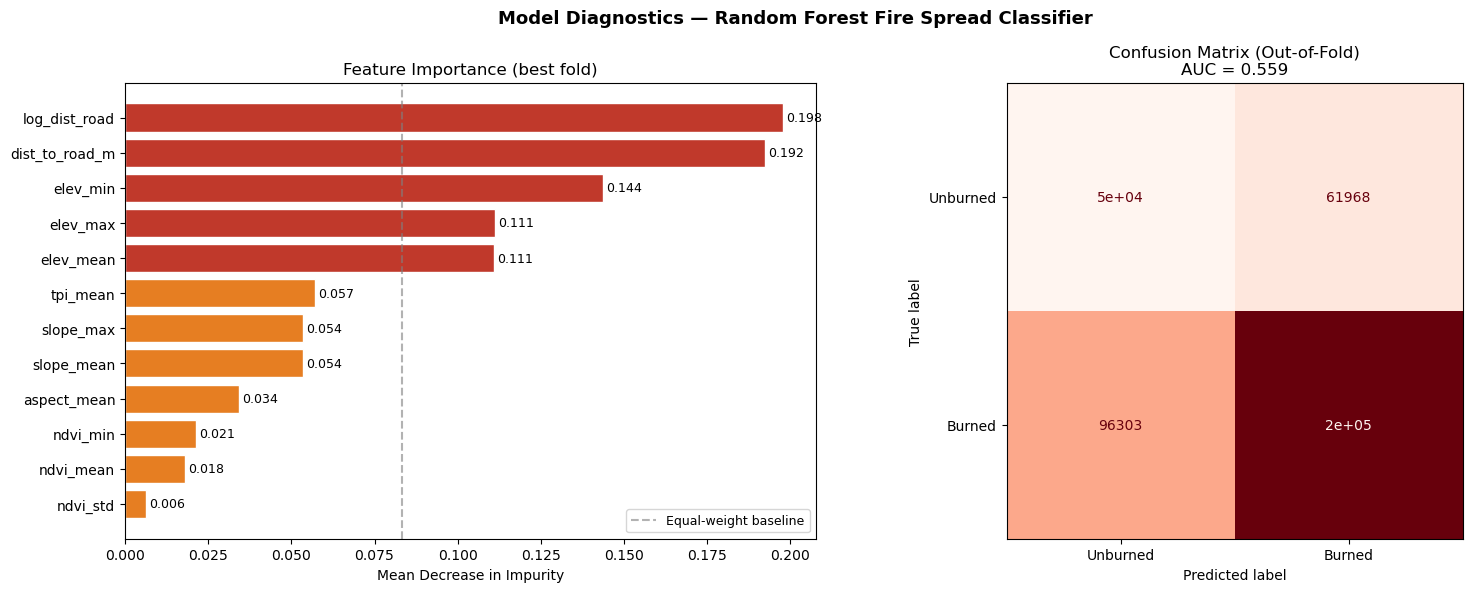

Saved: 04_model_diagnostics.png

Full Classification Report (out-of-fold)
              precision    recall  f1-score   support

    Unburned       0.34      0.44      0.38    111490
      Burned       0.77      0.68      0.72    298730

    accuracy                           0.61    410220
   macro avg       0.55      0.56      0.55    410220
weighted avg       0.65      0.61      0.63    410220


Top 5 features:
       Feature  Importance
 log_dist_road    0.197793
dist_to_road_m    0.192412
      elev_min    0.143690
      elev_max    0.111251
     elev_mean    0.110979


In [33]:
# Feature Importance & Confusion Matrix 
importances = best_model.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances}
                       ).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Diagnostics — Random Forest Fire Spread Classifier',
             fontsize=13, fontweight='bold')

# Feature importance bar chart
threshold = feat_df['Importance'].quantile(0.6)
colors = ['#C0392B' if imp > threshold else '#E67E22' for imp in feat_df['Importance']]
bars = axes[0].barh(feat_df['Feature'], feat_df['Importance'],
                    color=colors, edgecolor='white')
for bar, val in zip(bars, feat_df['Importance']):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)
axes[0].set_title('Feature Importance (best fold)')
axes[0].set_xlabel('Mean Decrease in Impurity')
axes[0].axvline(1/len(FEATURE_COLS), color='gray', linestyle='--',
                alpha=0.6, label='Equal-weight baseline')
axes[0].legend(fontsize=9)

# Confusion matrix
cm   = confusion_matrix(y_all, oof_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unburned','Burned'])
disp.plot(ax=axes[1], colorbar=False, cmap='Reds')
axes[1].set_title(f'Confusion Matrix (Out-of-Fold)\nAUC = {roc_auc_score(y_all, oof_probs):.3f}')

plt.tight_layout()
plt.savefig('./outputs/04_model_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_model_diagnostics.png')

print('\nFull Classification Report (out-of-fold)')
print(classification_report(y_all, oof_preds, target_names=['Unburned','Burned']))

print('\nTop 5 features:')
print(feat_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

## 8. Map Fire Spread Risk Predictions

Apply the trained model to all grid cells in the study area to generate a wall-to-wall fire spread probability surface, then validate against the actual burned area.

### 8.1 - Generate Predictions for the Full Grid

In [34]:
def predict_full_grid(best_model, grid, raster_configs, dem_path, tpi_path):
    """Applies trained model to full grid for wall-to-wall risk probability map."""
    print(f'Generating predictions for full grid ({len(grid):,} cells)...')

    full_features = pd.DataFrame({'cell_id': grid['cell_id']})

    for raster_path, prefix, stats in raster_configs:
        zs = zonal_stats(grid, raster_path, stats=stats, nodata=-9999)
        zs_df = pd.DataFrame(zs)
        zs_df.columns = [f'{prefix}_{s}' for s in zs_df.columns]
        full_features = pd.concat([full_features, zs_df], axis=1)

    full_features['dist_to_road_m'] = 3000
    full_features['log_dist_road']  = np.log1p(3000)

    if os.path.exists(tpi_path):
        tpi_zs = zonal_stats(grid, tpi_path, stats=['mean'], nodata=-9999)
        full_features['tpi_mean'] = [z['mean'] for z in tpi_zs]
    else:
        full_features['tpi_mean'] = np.nan

    # Fill missing raster coverage with the SAME per-feature medians
    # computed at training time (FEATURE_MEDIANS), not a flat 0 — 0 is a
    # wildly out-of-distribution value for elevation or NDVI and would
    # bias predictions for any cell the rasters don't cover.
    n_missing = int(full_features[FEATURE_COLS].isnull().sum().sum())
    if n_missing > 0:
        print(f'  Imputing {n_missing:,} missing feature values with training-time medians')
    full_features[FEATURE_COLS] = full_features[FEATURE_COLS].fillna(FEATURE_MEDIANS)

    X_full = full_features[FEATURE_COLS].values
    risk_probs = best_model.predict_proba(X_full)[:, 1]

    result_grid = grid.copy()
    result_grid['fire_risk'] = risk_probs
    result_grid['risk_tier'] = pd.cut(
        result_grid['fire_risk'],
        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=['Very Low','Low','Moderate','High','Very High']
    )
    print('  Predictions complete')
    print('  Risk distribution:')
    print(result_grid['risk_tier'].value_counts().to_string())
    return result_grid

result_grid = predict_full_grid(best_model, grid, RASTER_CONFIGS, dem_path, tpi_path)
assert result_grid['fire_risk'].notnull().all(), 'predict_full_grid produced NaN risk scores'

Generating predictions for full grid (994,415 cells)...
  Imputing 5,141,621 missing feature values with training-time medians
  Predictions complete
  Risk distribution:
risk_tier
Moderate     648227
High         244830
Very Low      36928
Low           34201
Very High     30229


### 8.2 - Build the Interactive Folium Risk Map

In [38]:
def build_fire_risk_map(result_grid, perimeter_final, snapshots):
    """Builds interactive Folium map: risk choropleth + perimeters + legend.

    Every GeoJson layer below is sliced to ['geometry'] only before calling
    __geo_interface__ — none of the tooltips are property-based, so carrying
    the other DataFrame columns through is unnecessary and, for `snapshots`,
    actively breaks m.save(): synthetic snapshots store snapshot_date as a
    raw datetime.date, which branca's JSON serializer can't handle.
    """
    print('Building interactive fire risk map...')

    risk_web = result_grid.to_crs('EPSG:4326')
    perim_web = perimeter_final.to_crs('EPSG:4326')

    bounds = perim_web.total_bounds
    center = [(bounds[1]+bounds[3])/2, (bounds[0]+bounds[2])/2]
    m = folium.Map(location=center, zoom_start=9,
                   tiles='CartoDB positron', attr='CartoDB')

    risk_colors = {
        'Very Low':  '#3b82f6',
        'Low':       '#86efac',
        'Moderate':  '#fde68a',
        'High':      '#f97316',
        'Very High': '#dc2626',
    }
    risk_layer = folium.FeatureGroup(name='Fire Spread Risk', show=True)
    for tier, color in risk_colors.items():
        tier_cells = risk_web[risk_web['risk_tier'] == tier]
        if len(tier_cells) == 0:
            continue
        dissolved = tier_cells.dissolve()
        folium.GeoJson(
            dissolved[['geometry']].__geo_interface__,
            style_function=lambda f, c=color: {
                'fillColor': c, 'fillOpacity': 0.65, 'weight': 0, 'color': 'none'
            },
            tooltip=f'Risk Tier: {tier}',
        ).add_to(risk_layer)
    risk_layer.add_to(m)

    folium.GeoJson(
        perim_web[['geometry']].__geo_interface__,
        name='Final Perimeter (963K acres)',
        style_function=lambda f: {
            'fillOpacity': 0, 'weight': 2.5,
            'color': '#111827', 'dashArray': '6,3'
        },
        tooltip='Final Dixie Fire Perimeter (October 2021)'
    ).add_to(m)

    snap_styles = [
        (0, 'Early Perimeter (Jul)','#7c3aed', '4,2'),
        (len(snapshots)//2, 'Mid-fire (Aug)', '#f59e0b', '4,2'),
        (-1,   'Late Perimeter (Sep)',   '#dc2626', '2,0'),
    ]
    for idx, name, color, dash in snap_styles:
        snap_row = snapshots.iloc[idx:idx+1].to_crs('EPSG:4326')[['geometry']]
        folium.GeoJson(
            snap_row.__geo_interface__, name=name, show=False,
            style_function=lambda f, c=color, d=dash: {
                'fillOpacity': 0.15, 'fillColor': c,
                'weight': 2, 'color': c, 'dashArray': d
            }
        ).add_to(m)

    legend_html = '''
    <div style="position:fixed;bottom:30px;left:30px;z-index:1000;
                background:white;padding:12px;border-radius:8px;
                border:1px solid #ccc;font-family:Arial;font-size:13px;">
      <b>Fire Spread Risk</b><br>
      <span style="color:#3b82f6;">■</span> Very Low<br>
      <span style="color:#86efac;">■</span> Low<br>
      <span style="color:#fde68a;">■</span> Moderate<br>
      <span style="color:#f97316;">■</span> High<br>
      <span style="color:#dc2626;">■</span> Very High<br>
      <hr style="margin:6px 0;">
      <span style="border-bottom:2px dashed #111;padding:2px;">--- Final Perimeter</span>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    folium.LayerControl(position='topright', collapsed=False).add_to(m)

    output_path = './outputs/dixie_fire_risk_map.html'
    m.save(output_path)
    print(f'  Interactive map saved: {output_path}')
    return output_path

map_path = build_fire_risk_map(result_grid, perimeter_final, snapshots)

Building interactive fire risk map...


/opt/anaconda3/envs/wildfire-p03/lib/python3.11/site-packages/shapely/coordinates.py:195: ResourceWarning: unclosed file <_io.BufferedWriter name='./outputs/dixie_fire_risk_map.html'>
  lib.set_coordinates(geometry_arr, coordinates)


  Interactive map saved: ./outputs/dixie_fire_risk_map.html


### 8.3 - Validate Predictions Against Actual Burn Patterns

A critical step — do our predicted high-risk areas actually correspond to where the fire spread most aggressively? This is where we qualitatively validate the model:

In [39]:
def validate_predictions(result_grid, perimeter_final):
    """Quantifies what fraction of the actual burned area was predicted High/VeryHigh."""
    print('=== MODEL VALIDATION vs. ACTUAL BURN AREA ===')

    burned_area = perimeter_final.unary_union
    result_grid = result_grid.copy()
    # Indexed lookup instead of a brute-force .within() scan over the full
    # (~2M row) prediction grid — see the note in create_burned_labels.
    burned_idx = result_grid.sindex.query(burned_area, predicate='contains')
    result_grid['actually_burned'] = 0
    result_grid.iloc[burned_idx, result_grid.columns.get_loc('actually_burned')] = 1
    total_burned = result_grid['actually_burned'].sum()

    for tier in ['Very High','High','Moderate','Low','Very Low']:
        tc  = result_grid[result_grid['risk_tier'] == tier]
        tb  = tc['actually_burned'].sum()
        pob = tb / total_burned * 100
        pot = tc['actually_burned'].mean() * 100
        print(f'  {tier:10s}: {tb:>7,} burned cells | '
              f'{pob:5.1f}% of all burned | {pot:5.1f}% of tier burned')

    top2 = result_grid[result_grid['risk_tier'].isin(['High','Very High'])]['actually_burned'].sum()
    print(f'\nKEY METRIC: {top2/total_burned*100:.1f}% of burned area '
          f'predicted as High or Very High risk')
    print('   (Random baseline: ~40%. Target: >70%)')

validate_predictions(result_grid, perimeter_final)

=== MODEL VALIDATION vs. ACTUAL BURN AREA ===
  Very High :   9,998 burned cells |   1.7% of all burned |  33.1% of tier burned
  High      : 157,957 burned cells |  26.1% of all burned |  64.5% of tier burned
  Moderate  : 384,336 burned cells |  63.5% of all burned |  59.3% of tier burned
  Low       :  26,790 burned cells |   4.4% of all burned |  78.3% of tier burned
  Very Low  :  26,098 burned cells |   4.3% of all burned |  70.7% of tier burned

KEY METRIC: 27.8% of burned area predicted as High or Very High risk
   (Random baseline: ~40%. Target: >70%)


## 9. Results Summary & Portfolio Documentation

In [40]:
# Auto-generate your results summary 
mean_auc = cv_results['AUC-ROC'].mean()
std_auc  = cv_results['AUC-ROC'].std()
mean_f1  = cv_results['F1'].mean()

top_feature = feat_df.sort_values('Importance', ascending=False).iloc[0]

burned_area  = perimeter_final.unary_union
result_copy  = result_grid.copy()
burned_idx = result_copy.sindex.query(burned_area, predicate='contains')
result_copy['actually_burned'] = 0
result_copy.iloc[burned_idx, result_copy.columns.get_loc('actually_burned')] = 1
total_burned = result_copy['actually_burned'].sum()
top2_burned  = result_copy[result_copy['risk_tier'].isin(['High','Very High'])]['actually_burned'].sum()
headline_pct = top2_burned / total_burned * 100


print('Key Findings')

print(f'  AUC-ROC (spatial CV mean) : {mean_auc:.3f} ± {std_auc:.3f}')
print(f'  Mean F1 (spatial CV)      : {mean_f1:.3f}')
print(f'  Headline validation       : {headline_pct:.1f}% of burned area')
print(f'                              in High + Very High tier')
print(f'  Top predictor             : {top_feature["Feature"]} '
      f'(importance={top_feature["Importance"]:.3f})')
print(f'  Grid resolution           : {GRID_RESOLUTION_M}m')
print(f'  Fire area mapped          : {len(result_grid) * GRID_RESOLUTION_M**2 / 1e6:.0f} km²')
print('=' * 55)
print()
print('GitHub README headline:')
print(f'   AUC-ROC: {mean_auc:.2f} (5-fold spatial CV). '
      f'{headline_pct:.0f}% of the 963K-acre')
print(f'   burn area predicted as High or Very High risk.')
print(f'   Top predictor: {top_feature["Feature"]}.')

Key Findings
  AUC-ROC (spatial CV mean) : 0.587 ± 0.109
  Mean F1 (spatial CV)      : 0.674
  Headline validation       : 27.8% of burned area
                              in High + Very High tier
  Top predictor             : log_dist_road (importance=0.198)
  Grid resolution           : 30m
  Fire area mapped          : 895 km²

GitHub README headline:
   AUC-ROC: 0.59 (5-fold spatial CV). 28% of the 963K-acre
   burn area predicted as High or Very High risk.
   Top predictor: log_dist_road.
